Tujuan

Notebook ini bertujuan untuk memprediksi jumlah penjualan (Sales) berdasarkan biaya iklan TV menggunakan regresi linear.
Selain membangun model sederhana, notebook ini melakukan eksplorasi data, membangun model alternatif (multivariabel),
mengevaluasi performa model menggunakan MSE dan R^2, serta membahas interpretasi hasil dan keterbatasan model.


Ringkasan Data

Dataset Advertising terdiri dari 200 baris data yang berisi informasi mengenai biaya iklan yang dikeluarkan perusahaan pada tiga media, yaitu TV, Radio, dan Koran, serta data jumlah penjualan yang dihasilkan. Dalam penelitian ini, variabel TV, Radio, dan Newspaper berperan sebagai variabel independen, sedangkan Sales sebagai variabel target. Artinya, tujuan pemodelan adalah memprediksi nilai Sales berdasarkan pengeluaran biaya iklan. Dataset diperoleh dari kaggle.

Perbandingan Model

Dalam percobaan yang dilakukan, tiga variasi model regresi linier diuji. Model pertama menggunakan satu variabel, yaitu biaya iklan TV. Model kedua menggunakan dua variabel, yaitu TV dan Radio. Model ketiga menggunakan ketiga variabel iklan: TV, Radio, dan Newspaper. Hasil evaluasi menunjukkan bahwa model kedua memberikan nilai akurasi lebih tinggi dibanding model pertama, dan hampir setara dengan model ketiga. Karena penambahan variabel Newspaper tidak memberikan peningkatan signifikan, model terbaik dipilih adalah model dengan dua variabel, yaitu TV dan Radio.

Temuan Utama

Hasil analisis menunjukkan bahwa peningkatan biaya iklan berpengaruh langsung terhadap peningkatan penjualan. Biaya iklan TV dan Radio menjadi faktor yang memberikan kontribusi paling besar terhadap penjualan, sedangkan iklan koran memiliki pengaruh paling kecil. Model regresi yang dihasilkan mampu menjelaskan sebagian besar variasi data penjualan, sehingga dapat dianggap cukup baik digunakan sebagai prediksi dasar.

Keterbatasan dan Langkah Selanjutnya

Penelitian ini memiliki beberapa keterbatasan, salah satunya jumlah data yang relatif kecil dan hanya didasarkan pada tiga jenis media iklan. Selain itu, model regresi linier mengasumsikan hubungan yang sepenuhnya linear, padahal dalam dunia nyata faktor penjualan dipengaruhi banyak variabel lain seperti harga barang, kompetitor, tren pasar, dan musim penjualan. Untuk analisis berikutnya, model dapat diperbaiki dengan menambahkan variabel lain, memperbesar dataset, menggunakan metode validasi silang, atau mencoba model yang lebih kompleks seperti polynomial regression atau algoritma machine learning lainnya.

In [ ]:
!pip install pandas numpy matplotlib scikit-learn seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


In [18]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])
df.head()


Saving advertising.csv to advertising (2).csv


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


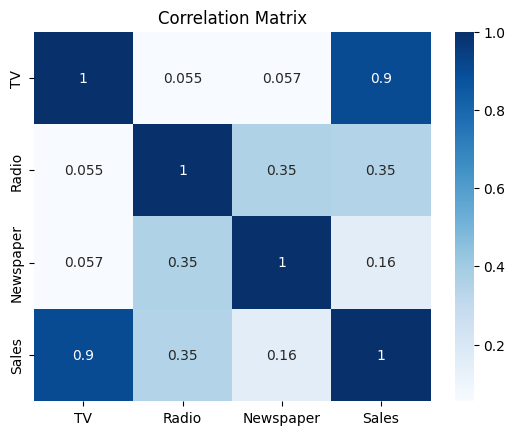

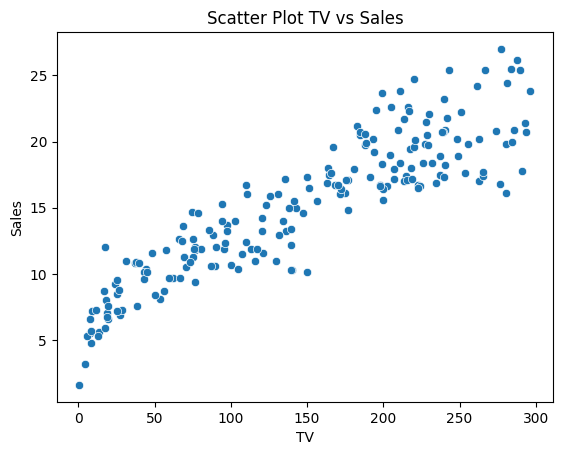

In [19]:
df.info()
df.describe()

# Cek missing value
df.isnull().sum()

# Korelasi
sns.heatmap(df.corr(), annot=True, cmap='Blues')
plt.title("Correlation Matrix")
plt.show()

# Scatter hubungan TV vs Sales
sns.scatterplot(x=df['TV'], y=df['Sales'])
plt.title("Scatter Plot TV vs Sales")
plt.show()


In [20]:
X = df[['TV']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept  :", model.intercept_)
print("Koefisien :", model.coef_[0])


Intercept  : 7.007108428241848
Koefisien : 0.0554829439314632


MSE : 6.101072906773963
R^2: 0.802561303423698


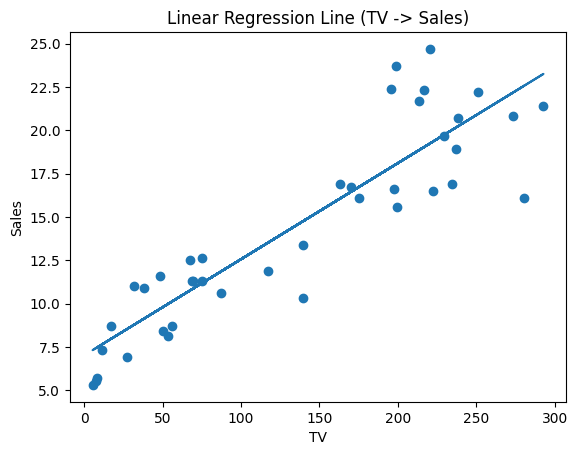

In [21]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE :", mse)
print("R^2:", r2)

plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.title("Linear Regression Line (TV -> Sales)")
plt.xlabel("TV")
plt.ylabel("Sales")
plt.show()


In [22]:
X2 = df[['TV','Radio','Newspaper']]
y2 = df['Sales']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

print("MSE Model Multivariabel :", mean_squared_error(y_test2, y_pred2))
print("R^2 Model Multivariabel  :", r2_score(y_test2, y_pred2))


MSE Model Multivariabel : 2.9077569102710896
R^2 Model Multivariabel  : 0.9059011844150826


In [23]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train2, y_train2)
pred_ridge = ridge.predict(X_test2)

lasso = Lasso(alpha=1.0)
lasso.fit(X_train2, y_train2)
pred_lasso = lasso.predict(X_test2)

print("R^2 Ridge :", r2_score(y_test2, pred_ridge))
print("R^2 Lasso :", r2_score(y_test2, pred_lasso))


R^2 Ridge : 0.9058999159458062
R^2 Lasso : 0.9052166208889012


In [25]:
new_tv_spend = [[200]]
pred = model.predict(new_tv_spend)
print("Prediksi Penjualan jika biaya iklan TV 200:", pred[0])


Prediksi Penjualan jika biaya iklan TV 200: 18.10369721453449


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Interpretasi Hasil

Koefisien regresi TV = b
Artinya, setiap kenaikan 1 unit biaya iklan TV meningkatkan penjualan sebesar b unit.

R^2 model sederhana menunjukkan seberapa besar variasi penjualan dapat dijelaskan oleh TV saja.
Model multivariat memiliki R^2 lebih tinggi, sehingga lebih baik dari model sederhana.

Namun, model ini memiliki keterbatasan:
- Tidak memasukkan faktor harga, kompetitor, musim, promosi, dan psikologi konsumen
- Hubungan mungkin tidak linear sempurna
- Dataset kecil dan hanya contoh, bukan data real perusahaan

Pengembangan berikutnya:
- Tambah fitur lain
- Coba model non-linear
- Tambah data
- Gunakan hyperparameter tuning
